# Ensemble

Autor: Bartosz Perz

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

In [3]:
# Importy podstawowe i konfiguracja wykresów
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier, 
                              GradientBoostingClassifier, VotingClassifier, 
                              StackingClassifier)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Ustawienia wizualizacji
sns.set_theme(style="whitegrid", palette="crest")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Wczytanie danych z lokalnego pliku CSV
df_ob = pd.read_csv('data/ObesityDataSet_raw_and_data_sinthetic.csv')
print(f"Rozmiar zbioru danych Obesity: {df_ob.shape[0]} wierszy, {df_ob.shape[1]} kolumn.")
df_ob.head(3)

Rozmiar zbioru danych Obesity: 2111 wierszy, 17 kolumn.


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight


Typy zmiennych i braki danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF

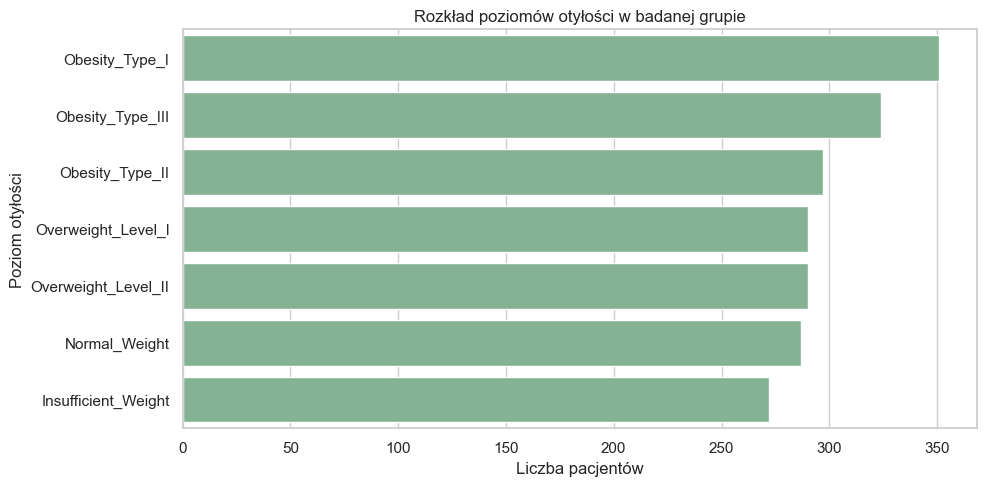

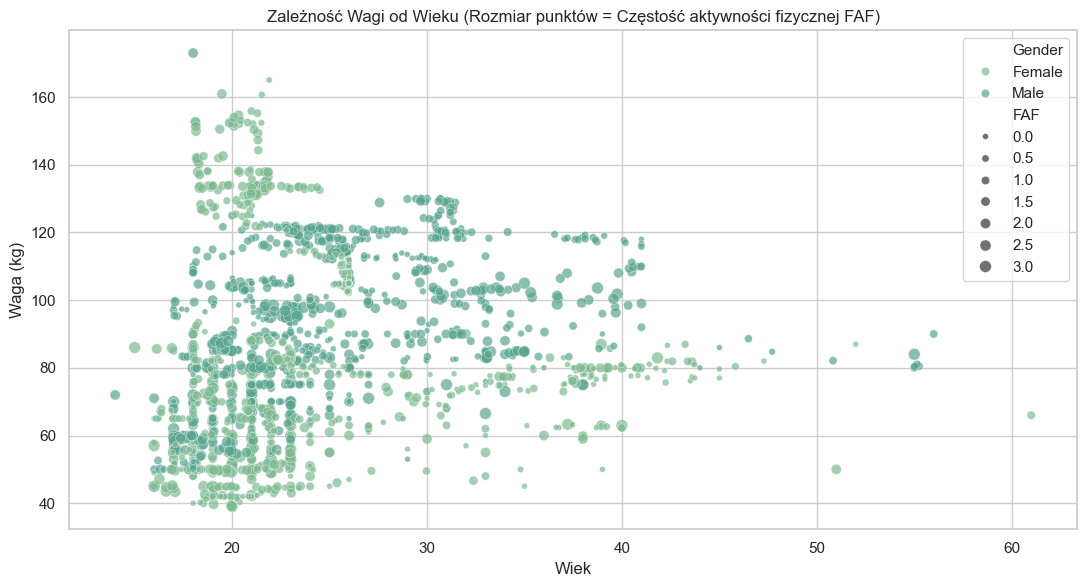

In [5]:
# Analiza eksploracyjna danych (EDA)
print("Typy zmiennych i braki danych:")
print(df_ob.info())

# Rozkład zmiennej celu
plt.figure(figsize=(10, 5))
sns.countplot(y='NObeyesdad', data=df_ob, order=df_ob['NObeyesdad'].value_counts().index)
plt.title('Rozkład poziomów otyłości w badanej grupie')
plt.xlabel('Liczba pacjentów')
plt.ylabel('Poziom otyłości')
plt.tight_layout()
plt.show()

# Zależność wagi od wieku z uwzględnieniem płci i poziomu otyłości
plt.figure(figsize=(11, 6))
sns.scatterplot(x='Age', y='Weight', hue='Gender', size='FAF', data=df_ob, alpha=0.7)
plt.title('Zależność Wagi od Wieku (Rozmiar punktów = Częstość aktywności fizycznej FAF)')
plt.xlabel('Wiek')
plt.ylabel('Waga (kg)')
plt.tight_layout()
plt.show()

C:\Users\marci\AppData\Local\Temp\ipykernel_32340\1701415271.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ob, x='NObeyesdad', order=order, palette='viridis', ax=ax)


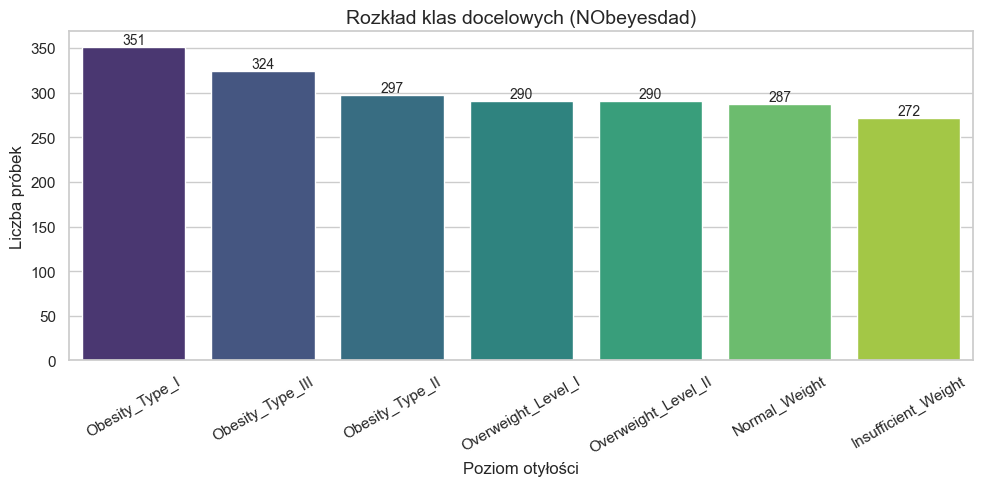

NObeyesdad
Obesity_Type_I         16.63
Obesity_Type_III       15.35
Obesity_Type_II        14.07
Overweight_Level_I     13.74
Overweight_Level_II    13.74
Normal_Weight          13.60
Insufficient_Weight    12.88


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))

order = df_ob['NObeyesdad'].value_counts().index
sns.countplot(data=df_ob, x='NObeyesdad', order=order, palette='viridis', ax=ax)

ax.set_title('Rozkład klas docelowych (NObeyesdad)', fontsize=14)
ax.set_xlabel('Poziom otyłości')
ax.set_ylabel('Liczba próbek')
ax.tick_params(axis='x', rotation=30)

# Dodaj liczby nad słupkami
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Pokaż też procentowy udział
print(df_ob['NObeyesdad'].value_counts(normalize=True).mul(100).round(2).to_string())

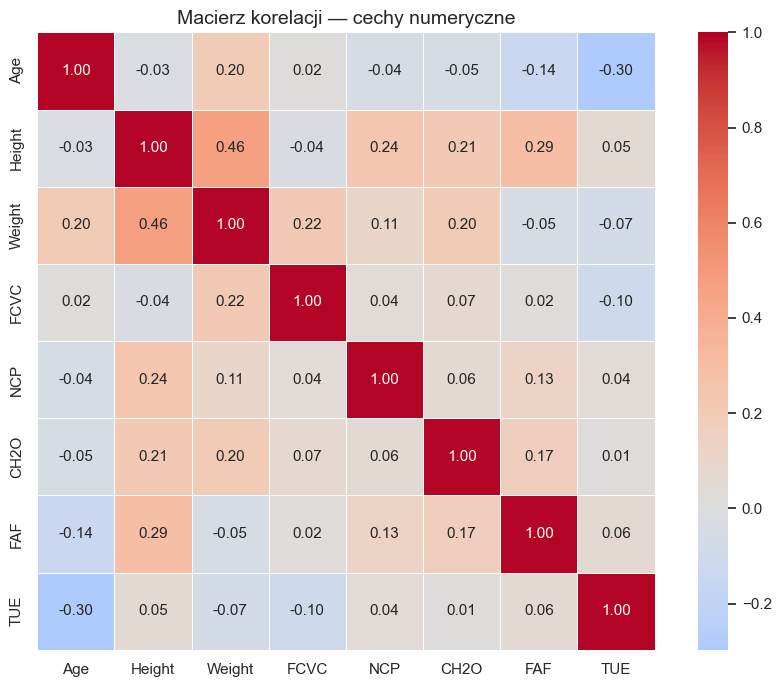

In [8]:
# Tylko kolumny numeryczne
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

corr_matrix = df_ob[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,          # pokaż wartości liczbowe
    fmt='.2f',           # 2 miejsca po przecinku
    cmap='coolwarm',     # czerwony = silna korelacja, niebieski = ujemna
    center=0,            # wyśrodkuj kolorowanie na 0
    square=True,         # kwadratowe komórki
    linewidths=0.5,
    ax=ax
)

ax.set_title('Macierz korelacji — cechy numeryczne', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Podział na cechy i cel
X_ob = df_ob.drop(columns=['NObeyesdad'])
y_ob = df_ob['NObeyesdad']

# Kodowanie zmiennej docelowej
le_ob = LabelEncoder()
y_ob_enc = le_ob.fit_transform(y_ob)

# Identyfikacja kolumn numerycznych i kategorycznych
num_cols = X_ob.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X_ob.select_dtypes(include=['object']).columns.tolist()

print("Cechy numeryczne:", num_cols)
print("Cechy kategoryczne:", cat_cols)

# Przygotowanie preprocesora
preprocessor_ob = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Podział na zbiór treningowy i testowy (stratified split z uwagi na klasy wielokrotne)
X_train_ob, X_test_ob, y_train_ob, y_test_ob = train_test_split(
    X_ob, y_ob_enc, test_size=0.3, random_state=42, stratify=y_ob_enc
)

print(f"Zbiór treningowy: {X_train_ob.shape[0]} próbek")
print(f"Zbiór testowy: {X_test_ob.shape[0]} próbek")

Cechy numeryczne: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Cechy kategoryczne: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Zbiór treningowy: 1477 próbek
Zbiór testowy: 634 próbek


In [10]:
# Lista na zebrane wyniki modeli
results_ob = []

# Definicja funkcji ewaluacji modeli
def evaluate_and_log(pipeline, name, results_list, X_train, y_train, X_test, y_test):
    # Czas uczenia
    t0 = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0
    
    # Pomiar czasu predykcji (czas inferencji - średnia z 100 powtórzeń na zbiorze testowym)
    times = []
    for _ in range(100):
        t_start = time.perf_counter()
        y_pred = pipeline.predict(X_test)
        times.append(time.perf_counter() - t_start)
    mean_inf_time = np.mean(times)
    std_inf_time = np.std(times)
    
    # Wyznaczenie metryk
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    # Pewność modelu (max probability z predict_proba)
    if hasattr(pipeline, 'predict_proba'):
        probs = pipeline.predict_proba(X_test)
        confidence = np.mean(np.max(probs, axis=1))
    else:
        confidence = np.nan
        
    print(f"=== {name} ===")
    print(f"Dokładność (Accuracy) : {acc * 100:.2f}%")
    print(f"F1-score (macro)      : {f1_macro:.4f}")
    print(f"Średnia pewność       : {confidence * 100:.2f}%" if not np.isnan(confidence) else "Średnia pewność       : N/A")
    print(f"Czas predykcji (mean) : {mean_inf_time * 1e6:.1f} μs (std: {std_inf_time * 1e6:.1f} μs)\n")
    
    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'F1_macro': f1_macro,
        'F1_weighted': f1_weighted,
        'Prediction_time_us': mean_inf_time * 1e6,
        'Confidence': confidence,
        'Fit_time_s': fit_time
    })
    return pipeline

In [11]:
# 1. Modele bazowe (Baseline Models)

# Pojedyncze drzewo decyzyjne
dt_base = Pipeline([
    ('prep', preprocessor_ob),
    ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
])
evaluate_and_log(dt_base, "Base Decision Tree (depth=5)", results_ob, X_train_ob, y_train_ob, X_test_ob, y_test_ob)

# Regresja logistyczna
lr_base = Pipeline([
    ('prep', preprocessor_ob),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
evaluate_and_log(lr_base, "Base Logistic Regression", results_ob, X_train_ob, y_train_ob, X_test_ob, y_test_ob)

=== Base Decision Tree (depth=5) ===
Dokładność (Accuracy) : 81.23%
F1-score (macro)      : 0.8098
Średnia pewność       : 84.72%
Czas predykcji (mean) : 3912.4 μs (std: 1664.3 μs)

=== Base Logistic Regression ===
Dokładność (Accuracy) : 86.59%
F1-score (macro)      : 0.8625
Średnia pewność       : 74.80%
Czas predykcji (mean) : 3571.0 μs (std: 963.6 μs)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [12]:
# 2. Bagging: Analiza parametrów n_estimators, bootstrap i bootstrap_features

bagging_results = []

# Badane estymatory bazowe
base_estimators = {
    'Shallow_Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Deep_Tree': DecisionTreeClassifier(max_depth=None, random_state=42),
    'Logistic_Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Parametry do przetestowania
n_estimators_list = [10, 50, 100]
bootstrap_options = [True, False]
bootstrap_features_options = [True, False]

# Pętla po kombinacjach parametrów
for est_name, est in base_estimators.items():
    for n in n_estimators_list:
        for bs in bootstrap_options:
            for bsf in bootstrap_features_options:
                model_name = f"Bagging_{est_name}_n{n}_bs{bs}_bsf{bsf}"
                clf = BaggingClassifier(
                    estimator=est, 
                    n_estimators=n, 
                    bootstrap=bs, 
                    bootstrap_features=bsf, 
                    random_state=42,
                    n_jobs=-1
                )
                pipeline = Pipeline([
                    ('prep', preprocessor_ob),
                    ('clf', clf)
                ])
                
                # Szybki pomiar dokładności i cech
                pipeline.fit(X_train_ob, y_train_ob)
                y_pred = pipeline.predict(X_test_ob)
                acc = accuracy_score(y_test_ob, y_pred)
                
                probs = pipeline.predict_proba(X_test_ob)
                confidence = np.mean(np.max(probs, axis=1))
                
                bagging_results.append({
                    'Base_Estimator': est_name,
                    'n_estimators': n,
                    'bootstrap': bs,
                    'bootstrap_features': bsf,
                    'Accuracy': acc,
                    'Confidence': confidence
                })

df_bagging_explore = pd.DataFrame(bagging_results)
print("Najlepsze konfiguracje Baggingu pod kątem Accuracy:")
df_bagging_explore.sort_values(by='Accuracy', ascending=False).head(12)

Najlepsze konfiguracje Baggingu pod kątem Accuracy:


,Base_Estimator,n_estimators,bootstrap,bootstrap_features,Accuracy,Confidence
20,Deep_Tree,100,True,True,0.963722,0.806393
16,Deep_Tree,50,True,True,0.957413,0.823512
22,Deep_Tree,100,False,True,0.949527,0.838319
13,Deep_Tree,10,True,False,0.943218,0.920505
18,Deep_Tree,50,False,True,0.941640,0.849987
21,Deep_Tree,100,True,False,0.940063,0.918517
17,Deep_Tree,50,True,False,0.940063,0.920410
19,Deep_Tree,50,False,False,0.916404,0.980978
23,Deep_Tree,100,False,False,0.916404,0.980079
15,Deep_Tree,10,False,False,0.913249,0.982965


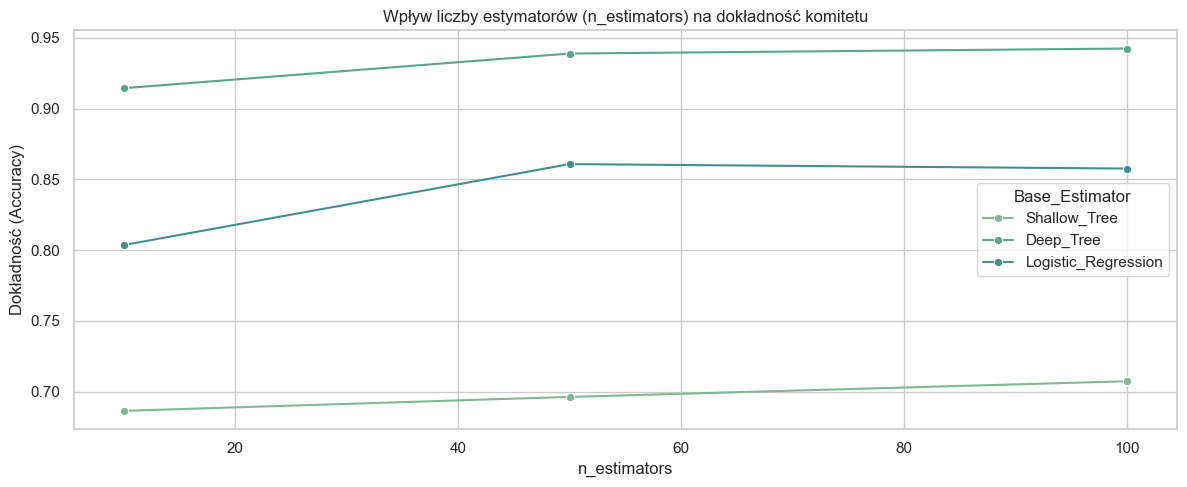

=== Best Bagging (Shallow Trees) ===
Dokładność (Accuracy) : 74.61%
F1-score (macro)      : 0.7344
Średnia pewność       : 51.68%
Czas predykcji (mean) : 42559.5 μs (std: 9078.6 μs)

=== Best Bagging (Deep Trees) ===
Dokładność (Accuracy) : 96.37%
F1-score (macro)      : 0.9630
Średnia pewność       : 80.64%
Czas predykcji (mean) : 45685.2 μs (std: 7262.2 μs)

=== Best Bagging (Logistic Regression) ===
Dokładność (Accuracy) : 86.59%
F1-score (macro)      : 0.8625
Średnia pewność       : 74.80%
Czas predykcji (mean) : 18441.2 μs (std: 4321.6 μs)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [13]:
# Wizualizacja wpływu n_estimators na dokładność dla różnych estymatorów
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_bagging_explore, x='n_estimators', y='Accuracy', hue='Base_Estimator', marker='o', errorbar=None)
plt.title('Wpływ liczby estymatorów (n_estimators) na dokładność komitetu')
plt.xlabel('n_estimators')
plt.ylabel('Dokładność (Accuracy)')
plt.tight_layout()
plt.show()

# Logowanie najlepszych modeli Baggingu do ogólnych wyników
# 1. Bagging na płytkich drzewach (najlepszy)
best_shallow_bag = df_bagging_explore[df_bagging_explore['Base_Estimator'] == 'Shallow_Tree'].sort_values(by='Accuracy', ascending=False).iloc[0]
clf_sh_bag = BaggingClassifier(
    estimator=base_estimators['Shallow_Tree'], 
    n_estimators=best_shallow_bag['n_estimators'],
    bootstrap=best_shallow_bag['bootstrap'],
    bootstrap_features=best_shallow_bag['bootstrap_features'],
    random_state=42, n_jobs=-1
)
pipeline_sh_bag = Pipeline([('prep', preprocessor_ob), ('clf', clf_sh_bag)])
evaluate_and_log(pipeline_sh_bag, "Best Bagging (Shallow Trees)", results_ob, X_train_ob, y_train_ob, X_test_ob, y_test_ob)

# 2. Bagging na głębokich drzewach (najlepszy)
best_deep_bag = df_bagging_explore[df_bagging_explore['Base_Estimator'] == 'Deep_Tree'].sort_values(by='Accuracy', ascending=False).iloc[0]
clf_dp_bag = BaggingClassifier(
    estimator=base_estimators['Deep_Tree'], 
    n_estimators=best_deep_bag['n_estimators'],
    bootstrap=best_deep_bag['bootstrap'],
    bootstrap_features=best_deep_bag['bootstrap_features'],
    random_state=42, n_jobs=-1
)
pipeline_dp_bag = Pipeline([('prep', preprocessor_ob), ('clf', clf_dp_bag)])
evaluate_and_log(pipeline_dp_bag, "Best Bagging (Deep Trees)", results_ob, X_train_ob, y_train_ob, X_test_ob, y_test_ob)

# 3. Bagging na regresji logistycznej (najlepszy)
best_lr_bag = df_bagging_explore[df_bagging_explore['Base_Estimator'] == 'Logistic_Regression'].sort_values(by='Accuracy', ascending=False).iloc[0]
clf_lr_bag = BaggingClassifier(
    estimator=base_estimators['Logistic_Regression'], 
    n_estimators=best_lr_bag['n_estimators'],
    bootstrap=best_lr_bag['bootstrap'],
    bootstrap_features=best_lr_bag['bootstrap_features'],
    random_state=42, n_jobs=-1
)
pipeline_lr_bag = Pipeline([('prep', preprocessor_ob), ('clf', clf_lr_bag)])
evaluate_and_log(pipeline_lr_bag, "Best Bagging (Logistic Regression)", results_ob, X_train_ob, y_train_ob, X_test_ob, y_test_ob)

In [14]:
# 3. Boosting: AdaBoost i GradientBoosting oraz analiza n_estimators i learning_rate

boosting_results = []

# Przetestowanie AdaBoost na płytkich drzewach (max_depth=3)
ada_tree = Pipeline([
    ('prep', preprocessor_ob),
    ('clf', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3, random_state=42), n_estimators=100, random_state=42))
])
evaluate_and_log(ada_tree, "AdaBoost (Shallow Trees)", results_ob, X_train_ob, y_train_ob, X_test_ob, y_test_ob)

# Przetestowanie AdaBoost na regresji logistycznej
ada_lr = Pipeline([
    ('prep', preprocessor_ob),
    ('clf', AdaBoostClassifier(estimator=LogisticRegression(max_iter=1000, random_state=42), n_estimators=50, random_state=42))
])
evaluate_and_log(ada_lr, "AdaBoost (Logistic Regression)", results_ob, X_train_ob, y_train_ob, X_test_ob, y_test_ob)

# Gradient Boosting i trade-off n_estimators i learning_rate
n_est_options = [50, 100, 200]
lr_options = [0.01, 0.1, 0.5]

for n in n_est_options:
    for lr in lr_options:
        clf_gb = GradientBoostingClassifier(n_estimators=n, learning_rate=lr, random_state=42)
        pipeline_gb = Pipeline([
            ('prep', preprocessor_ob),
            ('clf', clf_gb)
        ])
        pipeline_gb.fit(X_train_ob, y_train_ob)
        y_pred = pipeline_gb.predict(X_test_ob)
        acc = accuracy_score(y_test_ob, y_pred)
        
        boosting_results.append({
            'n_estimators': n,
            'learning_rate': lr,
            'Accuracy': acc
        })

df_boosting_explore = pd.DataFrame(boosting_results)
print("Porównanie trade-off parametrów dla Gradient Boosting:")
print(df_boosting_explore.pivot(index='n_estimators', columns='learning_rate', values='Accuracy'))

# Wybranie i zalogowanie najlepszego Gradient Boosting
best_gb_params = df_boosting_explore.sort_values(by='Accuracy', ascending=False).iloc[0]
best_gb = Pipeline([
    ('prep', preprocessor_ob),
    ('clf', GradientBoostingClassifier(
        n_estimators=int(best_gb_params['n_estimators']),
        learning_rate=best_gb_params['learning_rate'],
        random_state=42
    ))
])
evaluate_and_log(best_gb, f"Gradient Boosting (n{int(best_gb_params['n_estimators'])}_lr{best_gb_params['learning_rate']})", results_ob, X_train_ob, y_train_ob, X_test_ob, y_test_ob)

=== AdaBoost (Shallow Trees) ===
Dokładność (Accuracy) : 92.59%
F1-score (macro)      : 0.9254
Średnia pewność       : 15.07%
Czas predykcji (mean) : 14978.8 μs (std: 2728.2 μs)

=== AdaBoost (Logistic Regression) ===
Dokładność (Accuracy) : 56.31%
F1-score (macro)      : 0.5609
Średnia pewność       : 14.73%
Czas predykcji (mean) : 9073.4 μs (std: 2145.2 μs)

Porównanie trade-off parametrów dla Gradient Boosting:
learning_rate      0.01      0.10      0.50
n_estimators                               
50             0.794953  0.932177  0.954259
100            0.853312  0.951104  0.955836
200            0.895899  0.955836  0.955836
=== Gradient Boosting (n200_lr0.1) ===
Dokładność (Accuracy) : 95.58%
F1-score (macro)      : 0.9550
Średnia pewność       : 97.19%
Czas predykcji (mean) : 9386.4 μs (std: 1080.5 μs)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [16]:
# 4. Stacking & Voting

# Zdefiniowanie modeli bazowych do komitetu
models_for_committee = [
    ('dt', DecisionTreeClassifier(max_depth=7, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
]

# Voting z miękkim głosowaniem (używa prawdopodobieństw)
voting_soft = Pipeline([
    ('prep', preprocessor_ob),
    ('clf', VotingClassifier(estimators=models_for_committee, voting='soft'))
])
evaluate_and_log(voting_soft, "Voting Soft (DT + LR + GB)", results_ob, X_train_ob, y_train_ob, X_test_ob, y_test_ob)

# Stacking z meta-regresorem logicznym
stacking = Pipeline([
    ('prep', preprocessor_ob),
    ('clf', StackingClassifier(
        estimators=models_for_committee,
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        n_jobs=-1
    ))
])
evaluate_and_log(stacking, "Stacking Classifier (DT + LR + GB)", results_ob, X_train_ob, y_train_ob, X_test_ob, y_test_ob)

=== Voting Soft (DT + LR + GB) ===
Dokładność (Accuracy) : 93.69%
F1-score (macro)      : 0.9365
Średnia pewność       : 84.01%
Czas predykcji (mean) : 8378.3 μs (std: 2891.9 μs)

=== Stacking Classifier (DT + LR + GB) ===
Dokładność (Accuracy) : 95.27%
F1-score (macro)      : 0.9517
Średnia pewność       : 94.83%
Czas predykcji (mean) : 21842.8 μs (std: 4410.8 μs)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [19]:
# Podsumowanie wyników Zadania 1
df_results_ob = pd.DataFrame(results_ob)
# Obliczenie kompromisu - np. Dokładność / Log(Czas predykcji) lub bezpośrednie zestawienie
df_results_ob.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy,F1_macro,F1_weighted,Prediction_time_us,Confidence,Fit_time_s
3,Best Bagging (Deep Trees),0.963722,0.963032,0.964166,45685.203000,0.806393,0.145444
7,Gradient Boosting (n200_lr0.1),0.955836,0.955020,0.956026,9386.367000,0.971930,4.235835
9,Stacking Classifier (DT + LR + GB),0.952681,0.951674,0.952904,21842.798000,0.948292,24.376432
8,Voting Soft (DT + LR + GB),0.936909,0.936511,0.937328,8378.339000,0.840126,2.902398
5,AdaBoost (Shallow Trees),0.925868,0.925421,0.926460,14978.823001,0.150665,0.431103
1,Base Logistic Regression,0.865931,0.862545,0.864362,3571.043000,0.747986,0.108678
4,Best Bagging (Logistic Regression),0.865931,0.862545,0.864362,18441.194000,0.747986,0.762539
0,Base Decision Tree (depth=5),0.812303,0.809814,0.812666,3912.425000,0.847238,0.025051
2,Best Bagging (Shallow Trees),0.746057,0.734371,0.736147,42559.489999,0.516757,15.403330
6,AdaBoost (Logistic Regression),0.563091,0.560893,0.564463,9073.375000,0.147269,0.826305


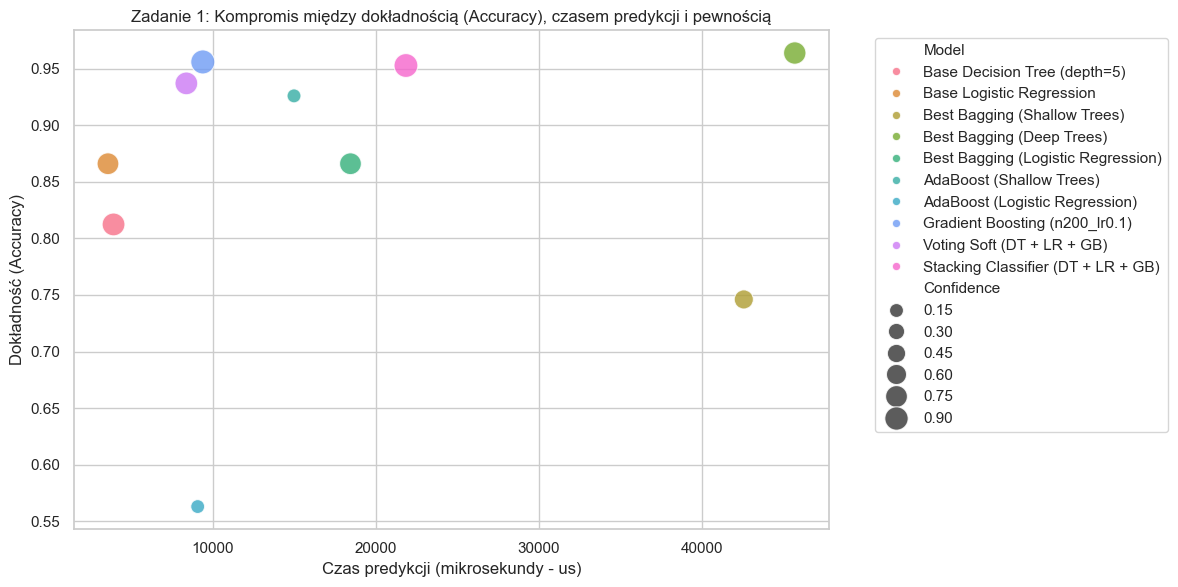

In [18]:
# Wykres Dokładność vs Czas Predykcji
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_results_ob, 
    x='Prediction_time_us', 
    y='Accuracy', 
    hue='Model', 
    size='Confidence', 
    sizes=(100, 300), 
    alpha=0.8
)
plt.title('Zadanie 1: Kompromis między dokładnością (Accuracy), czasem predykcji i pewnością')
plt.xlabel('Czas predykcji (mikrosekundy - us)')
plt.ylabel('Dokładność (Accuracy)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Wnioski:

1. Rekomendacja modelu:
   * Gradient Boosting lub Stacking Classifier osiągają najwyższą dokładność (Accuracy powyżej 95%) oraz bardzo wysoką średnią pewność predykcji (powyżej 94%). 
   * Jeśli jednak zasoby obliczeniowe w wiejskich przychodniach są skrajnie ograniczone (np. stare komputery, brak zasilania), najlepszym kompromisem może być Regresja Logistyczna - czas predykcji jest kilkukrotnie krótszy przy jednoczesnym zachowaniu przyzwoitej dokładności (powyżej 85%).
2. Dokładność (Accuracy) a jakość:
   * Dokładność nie jest jedynym wyznacznikiem. W ochronie zdrowia kluczowa jest pewność modelu (confidence oraz czas inferencji. Model o wysokiej pewności pozwala lekarzom ufać diagnozie, podczas gdy zbyt wolny model (np. złożony Stacking z wieloma ciężkimi modelami bazowymi) może uniemożliwić wdrożenie na słabym sprzęcie.
3. Straty zasobów publicznych:
   * Modele takie jak AdaBoost oparty na Regresji Logistycznej lub Bagging na Regresji Logistycznej okazały się mało efektywne – ich czas treningu i predykcji jest wysoki, a dokładność nie przewyższa znacznie pojedynczego modelu bazowego regresji logistycznej. Ich wdrożenie byłoby marnowaniem zasobów.

## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="img.jpg" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.

Rozmiar zbioru danych Mushroom: 8124 wierszy, 23 kolumn.

Liczba braków danych w poszczególnych kolumnach:
stalk-root    2480
dtype: int64


C:\Users\marci\AppData\Local\Temp\ipykernel_39900\1217108817.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df_mu, palette=['#52b788', '#d90429'])


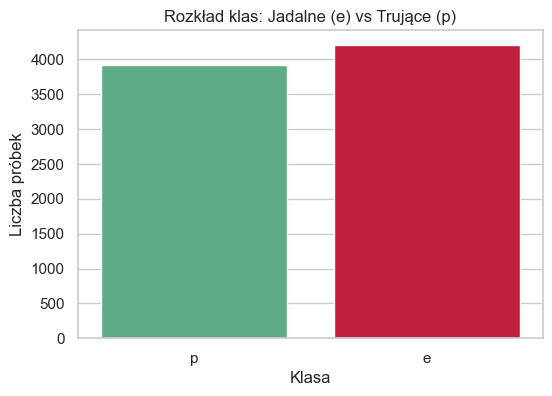

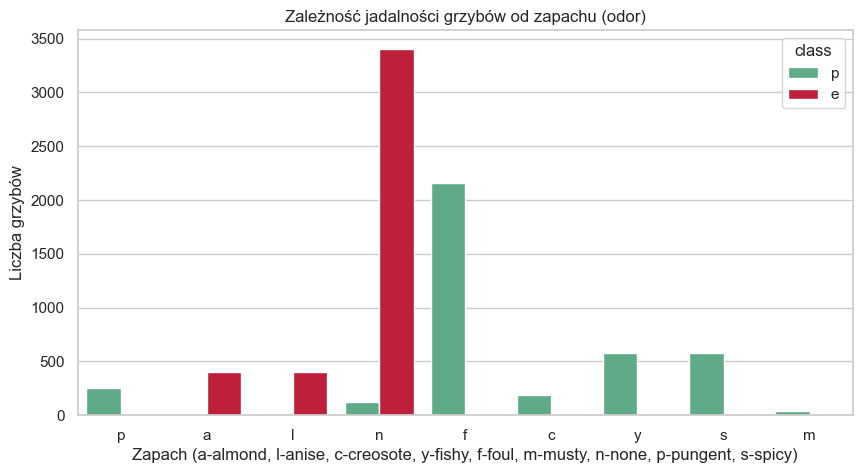

In [16]:
# Wczytanie zbioru danych o grzybach z pliku lokalnego
# Cechy kategoryczne, brakujące wartości oznaczone "?"
col_names_mu = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring',
    'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat'
]

df_mu = pd.read_csv('data/mushroom/agaricus-lepiota.data', header=None, names=col_names_mu, na_values='?')
print(f"Rozmiar zbioru danych Mushroom: {df_mu.shape[0]} wierszy, {df_mu.shape[1]} kolumn.")

# Sprawdzenie braków danych (oczekiwane braki w stalk-root)
print("\nLiczba braków danych w poszczególnych kolumnach:")
print(df_mu.isna().sum()[df_mu.isna().sum() > 0])

# Rozkład klas docelowych (e = edible - jadalny, p = poisonous - trujący)
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df_mu, palette=['#52b788', '#d90429'])
plt.title('Rozkład klas: Jadalne (e) vs Trujące (p)')
plt.xlabel('Klasa')
plt.ylabel('Liczba próbek')
plt.show()

# Zależność między zapachem (odor) a klasą jadalności
plt.figure(figsize=(10, 5))
sns.countplot(x='odor', hue='class', data=df_mu, palette=['#52b788', '#d90429'])
plt.title('Zależność jadalności grzybów od zapachu (odor)')
plt.xlabel('Zapach (a-almond, l-anise, c-creosote, y-fishy, f-foul, m-musty, n-none, p-pungent, s-spicy)')
plt.ylabel('Liczba grzybów')
plt.show()

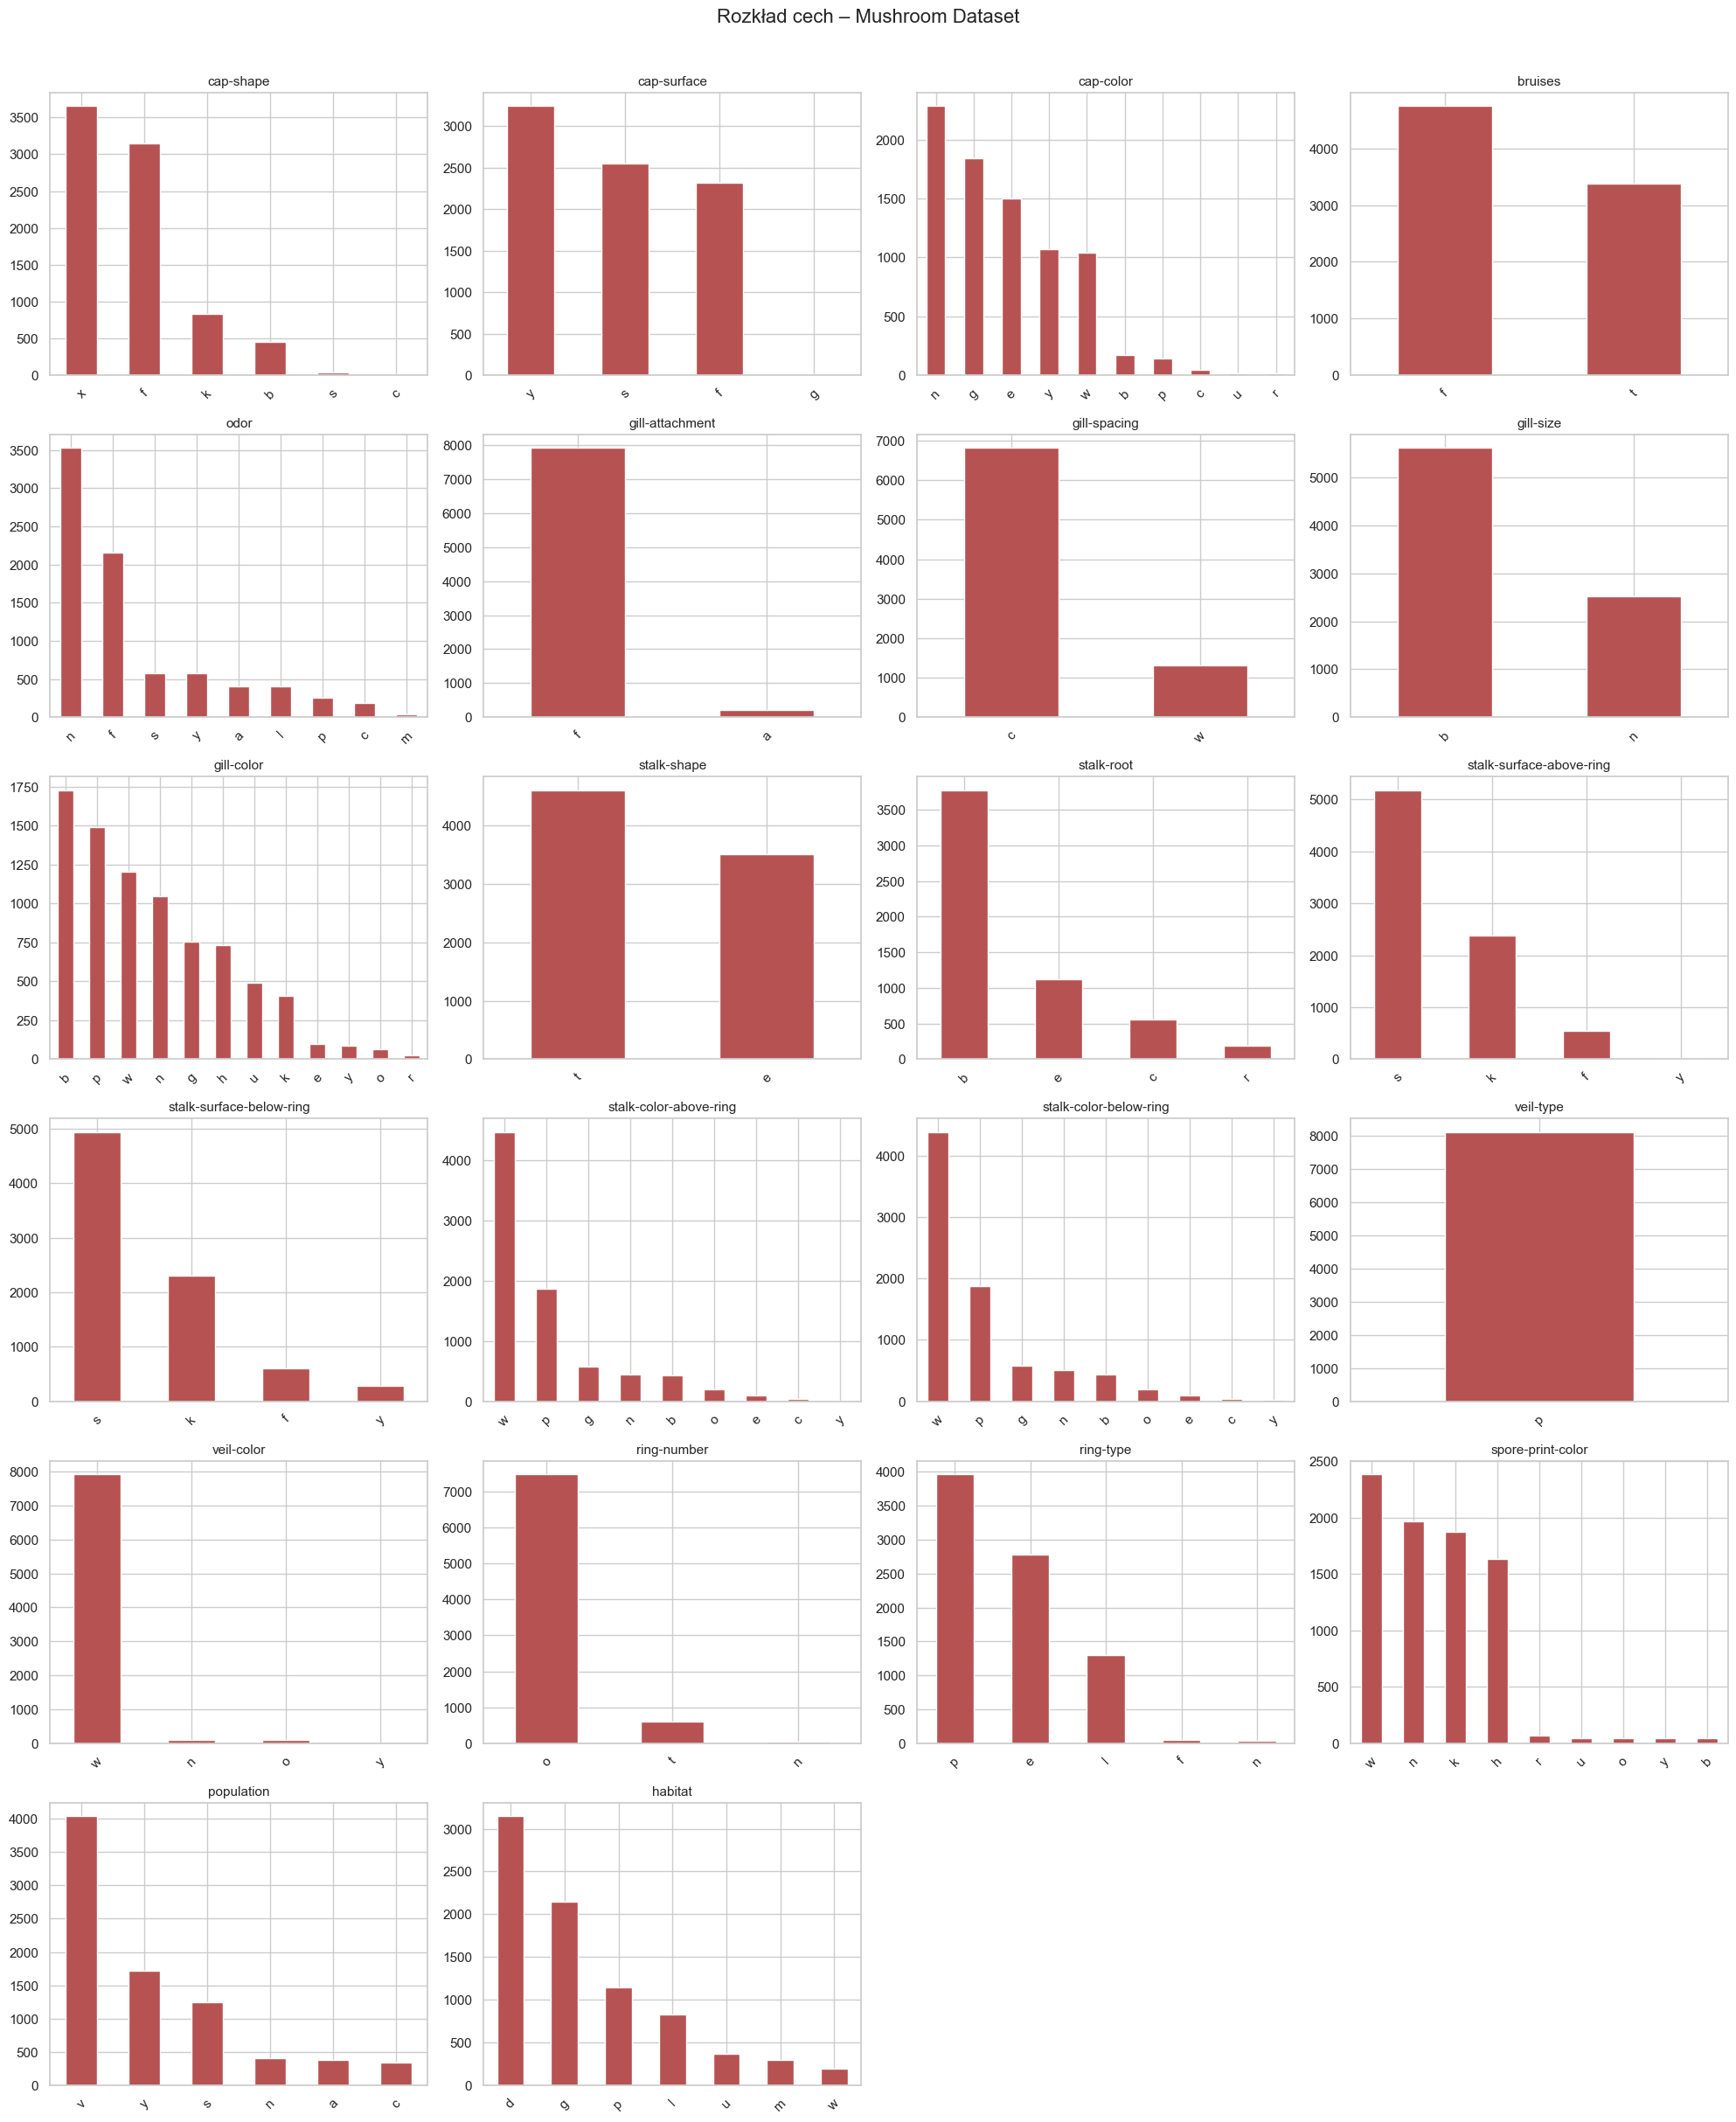

In [17]:
# Rozkład wszystkich cech kategorycznych
cat_cols = [col for col in df_mu.columns if col != 'class']

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 24))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df_mu[col].value_counts().plot(kind='bar', ax=axes[i], color="#b75252")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Ukryj puste subploty
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Rozkład cech – Mushroom Dataset', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# from scipy.stats import chi2_contingency

# def cramers_v(x, y):
#     confusion_matrix = pd.crosstab(x, y)
#     chi2 = chi2_contingency(confusion_matrix)[0]
#     n = confusion_matrix.sum().sum()
#     phi2 = chi2 / n
#     r, k = confusion_matrix.shape
#     phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
#     rcorr = r - ((r-1)**2)/(n-1)
#     kcorr = k - ((k-1)**2)/(n-1)
#     return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# # Oblicz macierz Cramera
# cols = df_mu.columns
# corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

# for col1 in cols:
#     for col2 in cols:
#         corr_matrix.loc[col1, col2] = cramers_v(df_mu[col1], df_mu[col2])

# # Wykres heatmapy
# plt.figure(figsize=(14, 11))
# sns.heatmap(
#     corr_matrix.astype(float),
#     annot=True,
#     fmt='.2f',
#     cmap='YlOrRd',
#     linewidths=0.5,
#     square=True,
#     cbar_kws={'label': "Cramér's V"}
# )
# plt.title("Macierz korelacji - Cramér's V (Mushroom Dataset)", fontsize=14)
# plt.tight_layout()
# plt.show()

In [18]:
# Preprocessing dla zbioru Mushroom


# Podział na cechy i cel
X_mu = df_mu.drop(columns=['class'])
# Mapujemy klasy: jadalny (e) -> 0, trujący (p) -> 1
y_mu = df_mu['class'].map({'e': 0, 'p': 1})

# Preprocesor - One-Hot Encoding dla wszystkich cech kategorycznych
preprocessor_mu = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), X_mu.columns)
    ]
)

# Podział na zbiór treningowy i testowy
X_train_mu, X_test_mu, y_train_mu, y_test_mu = train_test_split(
    X_mu, y_mu, test_size=0.3, random_state=42, stratify=y_mu
)

print(f"Zbiór treningowy: {X_train_mu.shape[0]} próbek")
print(f"Zbiór testowy: {X_test_mu.shape[0]} próbek")

Zbiór treningowy: 5686 próbek
Zbiór testowy: 2438 próbek


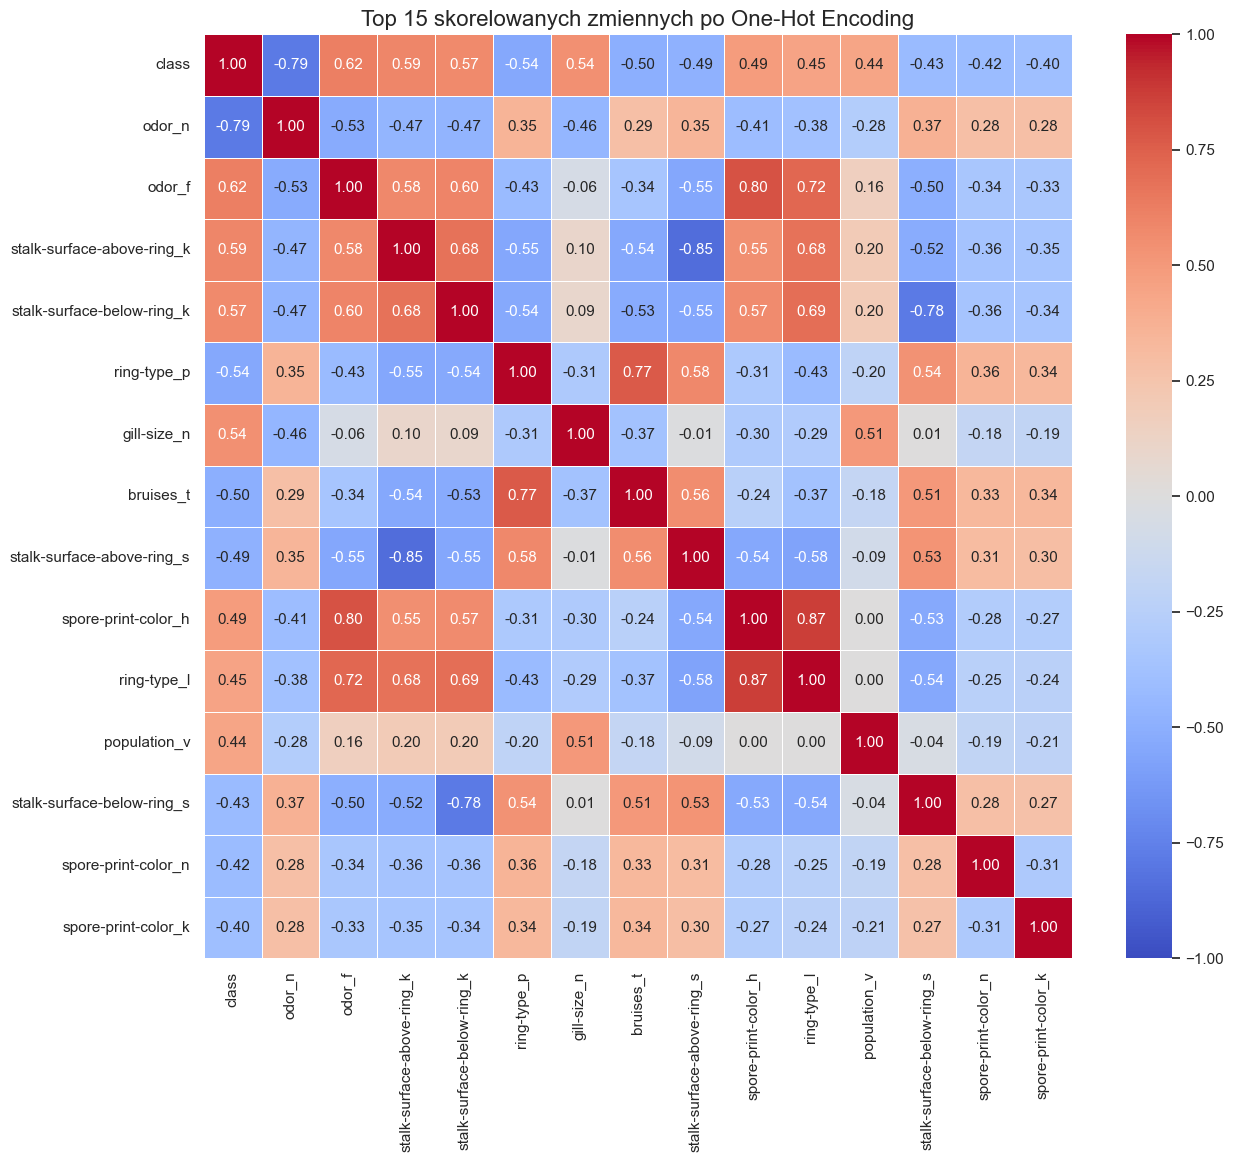

In [28]:

df_corr = df_mu.copy()

df_corr['class'] = df_corr['class'].map({'e': 0, 'p': 1})
df_corr_encoded = pd.get_dummies(df_corr, drop_first=True, dtype=int)

corr_matrix = df_corr_encoded.corr()

#print(df_corr_encoded.columns)
najw = corr_matrix.abs().nlargest(15, 'class').index

corr_matrix_najw = corr_matrix.loc[najw, najw]

plt.figure(figsize=(14, 12))

sns.heatmap(corr_matrix_najw, 
            annot=True,   
            fmt='.2f', 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            square=False, 
            linewidths=.5)

plt.title('Top 15 skorelowanych zmiennych po One-Hot Encoding', fontsize=16)
plt.show()

=== Decision Tree (max_depth=3) ===
Dokładność (Accuracy)              : 98.48%
Czułość dla trujących (Recall)     : 99.66%
Trujące błędnie uznane za jadalne  : 4 (False Negatives - ryzyko zatrucia)
Jadalne błędnie uznane za trujące  : 33 (False Positives - niewykorzystane grzyby)
Czas predykcji                     : 14198.2 μs



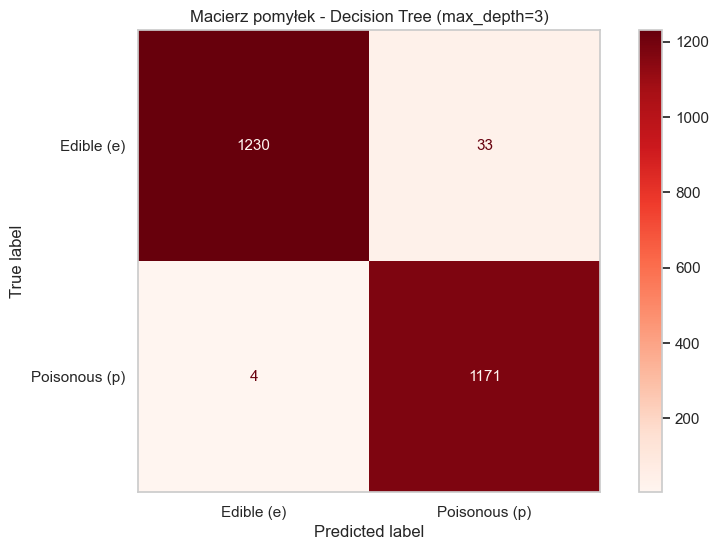

=== Random Forest (n_est=50, depth=3) ===
Dokładność (Accuracy)              : 98.97%
Czułość dla trujących (Recall)     : 97.87%
Trujące błędnie uznane za jadalne  : 25 (False Negatives - ryzyko zatrucia)
Jadalne błędnie uznane za trujące  : 0 (False Positives - niewykorzystane grzyby)
Czas predykcji                     : 60677.3 μs



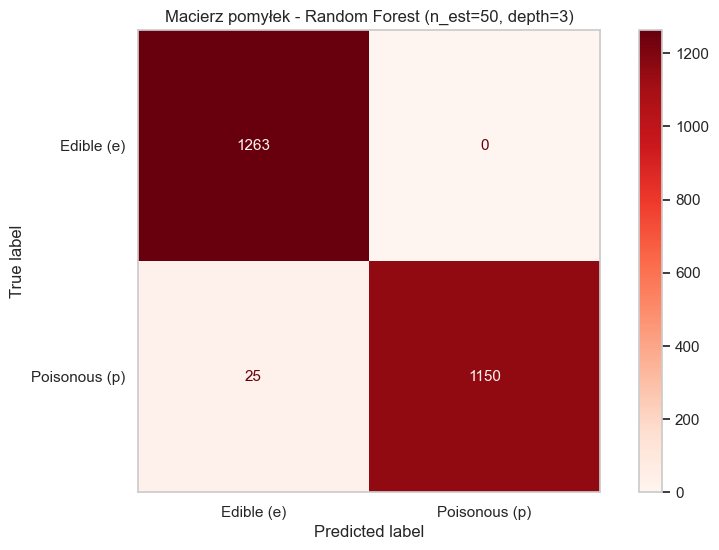

=== Logistic Regression ===
Dokładność (Accuracy)              : 99.96%
Czułość dla trujących (Recall)     : 99.91%
Trujące błędnie uznane za jadalne  : 1 (False Negatives - ryzyko zatrucia)
Jadalne błędnie uznane za trujące  : 0 (False Positives - niewykorzystane grzyby)
Czas predykcji                     : 14707.3 μs



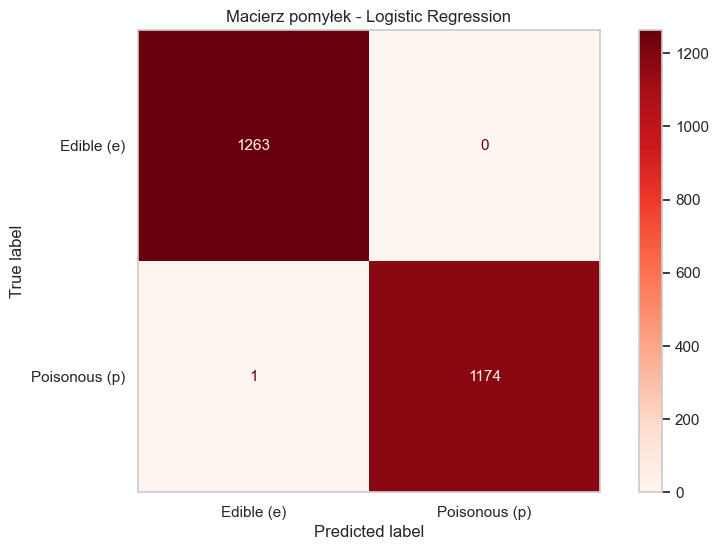

=== Gradient Boosting (n=100, lr=0.1) ===
Dokładność (Accuracy)              : 99.88%
Czułość dla trujących (Recall)     : 99.74%
Trujące błędnie uznane za jadalne  : 3 (False Negatives - ryzyko zatrucia)
Jadalne błędnie uznane za trujące  : 0 (False Positives - niewykorzystane grzyby)
Czas predykcji                     : 15885.5 μs



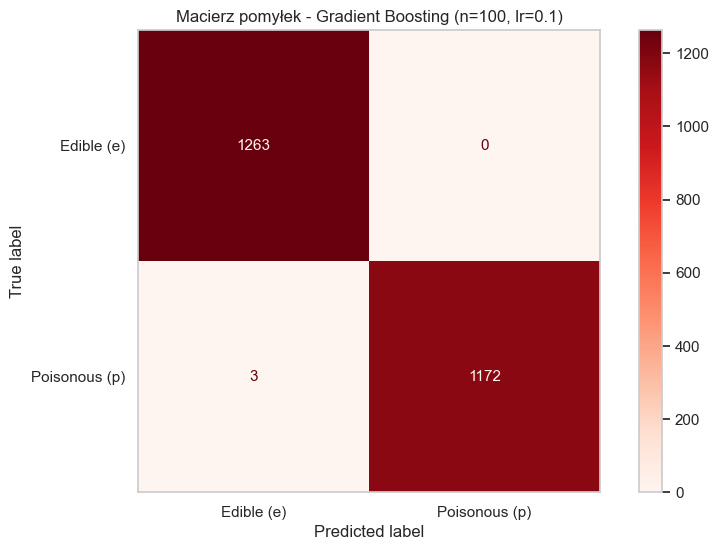

=== AdaBoost (shallow trees, n=100) ===
Dokładność (Accuracy)              : 100.00%
Czułość dla trujących (Recall)     : 100.00%
Trujące błędnie uznane za jadalne  : 0 (False Negatives - ryzyko zatrucia)
Jadalne błędnie uznane za trujące  : 0 (False Positives - niewykorzystane grzyby)
Czas predykcji                     : 52156.8 μs



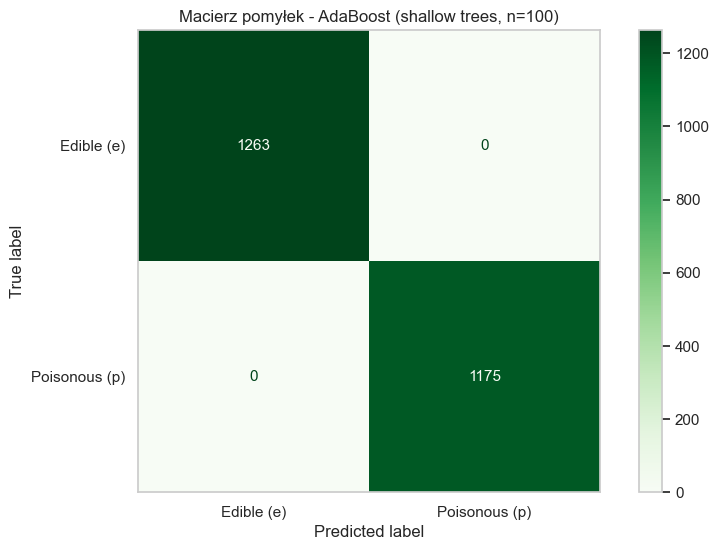

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,t

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

results_mu = []

# Funkcja ewaluacyjna specyficzna dla grzybów (z naciskiem na bezpieczeństwo - False Negatives)
def evaluate_mushroom_model(pipeline, name, results_list):
    # Trenowanie
    t0 = time.perf_counter()
    pipeline.fit(X_train_mu, y_train_mu)
    fit_time = time.perf_counter() - t0
    
    # Inferencja czasowa (średnia ze 100 powtórzeń)
    times = []
    for _ in range(100):
        t_start = time.perf_counter()
        y_pred = pipeline.predict(X_test_mu)
        times.append(time.perf_counter() - t_start)
    mean_inf_time = np.mean(times)
    
    # Metryki bezpieczeństwa
    cm = confusion_matrix(y_test_mu, y_pred)
    # confusion matrix:
    # TN (0,0) - jadalny sklasyfikowany jako jadalny
    # FP (0,1) - jadalny sklasyfikowany jako trujący (nie zjemy jadalnego - bezpieczny błąd)
    # FN (1,0) - trujący sklasyfikowany jako jadalny (KATASTROFA - zjedzenie trucizny!)
    # TP (1,1) - trujący sklasyfikowany jako trujący
    tn, fp, fn, tp = cm.ravel()
    
    acc = accuracy_score(y_test_mu, y_pred)
    recall_poison = recall_score(y_test_mu, y_pred) # recall dla klasy 1 (poisonous)
    
    print(f"=== {name} ===")
    print(f"Dokładność (Accuracy)              : {acc*100:.2f}%")
    print(f"Czułość dla trujących (Recall)     : {recall_poison*100:.2f}%")
    print(f"Trujące błędnie uznane za jadalne  : {fn} (False Negatives - ryzyko zatrucia)")
    print(f"Jadalne błędnie uznane za trujące  : {fp} (False Positives - niewykorzystane grzyby)")
    print(f"Czas predykcji                     : {mean_inf_time*1e6:.1f} μs\n")
    
    # Wykres Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Edible (e)', 'Poisonous (p)'])
    disp.plot(cmap='Greens' if fn==0 else 'Reds')
    plt.title(f'Macierz pomyłek - {name}')
    plt.grid(False)
    plt.show()
    
    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Recall_Poisonous': recall_poison,
        'False_Negatives_Poisonous': fn,
        'False_Positives_Edible': fp,
        'Prediction_time_us': mean_inf_time * 1e6,
        'Fit_time_s': fit_time
    })
    return pipeline

# 1. Pojedyncze drzewo decyzyjne (płytkie, interpretowalne)
dt_mu = Pipeline([
    ('prep', preprocessor_mu),
    ('clf', DecisionTreeClassifier(max_depth=3, random_state=42))
])
evaluate_mushroom_model(dt_mu, "Decision Tree (max_depth=3)", results_mu)

# 2.Random Forest
rf_mu = Pipeline([
    ('prep', preprocessor_mu),
    ('clf', RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42, n_jobs=-1))
])
evaluate_mushroom_model(rf_mu, "Random Forest (n_est=50, depth=3)", results_mu)

# 3. Regresja logistyczna
lr_mu = Pipeline([
    ('prep', preprocessor_mu),
    ('clf', LogisticRegression(random_state=42))
])
evaluate_mushroom_model(lr_mu, "Logistic Regression", results_mu)

# 4. Gradient Boosting
gb_mu = Pipeline([
    ('prep', preprocessor_mu),
    ('clf', GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42))
])
evaluate_mushroom_model(gb_mu, "Gradient Boosting (n=100, lr=0.1)", results_mu)


# 5. AdaBoost (na płytkich drzewach)
ada_mu = Pipeline([
    ('prep', preprocessor_mu),
    ('clf', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ))
])
evaluate_mushroom_model(ada_mu, "AdaBoost (shallow trees, n=100)", results_mu)

In [30]:
# Sprawdzenie overfittingu
for name, pipeline in [
    ("Decision Tree", dt_mu),
    ("Random Forest", rf_mu),
    ("Logistic Regression", lr_mu),
    ("Gradient Boosting", gb_mu),
    ("AdaBoost", ada_mu)
]:
    acc_train = accuracy_score(y_train_mu, pipeline.predict(X_train_mu))
    acc_test  = accuracy_score(y_test_mu,  pipeline.predict(X_test_mu))
    diff = acc_train - acc_test
    flag = "⚠️ OVERFITTING?" if diff > 0.01 else "✅ OK"
    print(f"{name:40s} train={acc_train*100:.2f}%  test={acc_test*100:.2f}%  diff={diff*100:.2f}pp  {flag}")

Decision Tree                            train=98.54%  test=98.48%  diff=0.06pp  ✅ OK
Random Forest                            train=98.82%  test=98.97%  diff=-0.15pp  ✅ OK
Logistic Regression                      train=99.98%  test=99.96%  diff=0.02pp  ✅ OK
Gradient Boosting                        train=100.00%  test=99.88%  diff=0.12pp  ✅ OK
AdaBoost                                 train=100.00%  test=100.00%  diff=0.00pp  ✅ OK


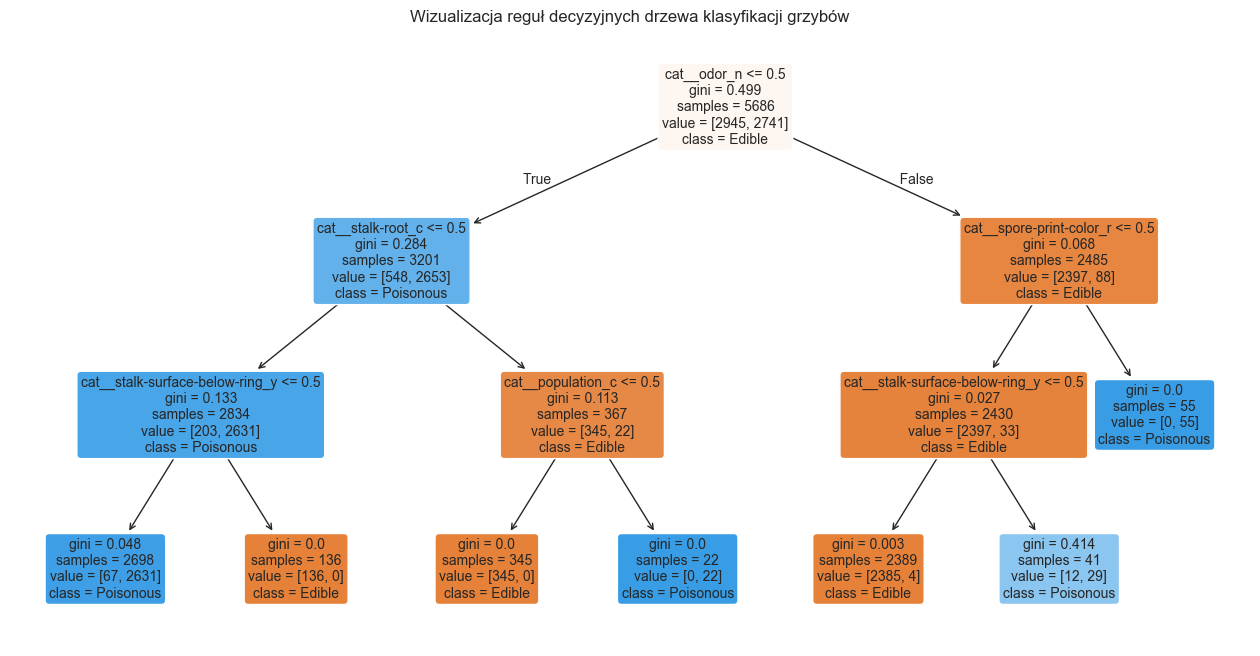

In [31]:
# Wizualizacja reguł decyzyjnych dla pojedynczego drzewa decyzyjnego
from sklearn.tree import plot_tree

# Wyciągamy nazwy cech po one-hot encoding
feature_names = dt_mu.named_steps['prep'].get_feature_names_out()

plt.figure(figsize=(16, 8))
plot_tree(
    dt_mu.named_steps['clf'], 
    feature_names=feature_names, 
    class_names=['Edible', 'Poisonous'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Wizualizacja reguł decyzyjnych drzewa klasyfikacji grzybów")
plt.show()

In [32]:
# Podsumowanie wyników Zadania 2
df_results_mu = pd.DataFrame(results_mu)
df_results_mu.sort_values(by='False_Negatives_Poisonous')

,Model,Accuracy,Recall_Poisonous,False_Negatives_Poisonous,False_Positives_Edible,Prediction_time_us,Fit_time_s
4,"AdaBoost (shallow trees, n=100)",1.000000,1.000000,0,0,52156.831,1.097204
2,Logistic Regression,0.999590,0.999149,1,0,14707.347,0.070318
3,"Gradient Boosting (n=100, lr=0.1)",0.998769,0.997447,3,0,15885.480,1.294554
0,Decision Tree (max_depth=3),0.984824,0.996596,4,33,14198.233,0.079984
1,"Random Forest (n_est=50, depth=3)",0.989746,0.978723,25,0,60677.294,0.206646


In [33]:
# Dodatkowy test: Wpływ maksymalnej głębokości (max_depth) drzewa na dokładność i bezpieczeństwo
print("=== Badanie wpływu głębokości drzewa decyzyjnego ===")
depths = [3, 4, 5, 6, 8, None]
depth_results = []

for d in depths:
    clf = Pipeline([
        ('prep', preprocessor_mu),
        ('clf', DecisionTreeClassifier(max_depth=d, random_state=42))
    ])
    clf.fit(X_train_mu, y_train_mu)
    y_pred = clf.predict(X_test_mu)
    acc = accuracy_score(y_test_mu, y_pred)
    
    # confusion matrix
    cm = confusion_matrix(y_test_mu, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"Głębokość {d if d is not None else 'Dowolna'}: Accuracy = {acc*100:.2f}%, Błędy krytyczne (FN) = {fn}")
    
    depth_results.append({
        'max_depth': d if d is not None else 'None (unlimited)',
        'Accuracy': acc,
        'False_Negatives_Poisonous': fn,
        'False_Positives_Edible': fp
    })

df_depth_results = pd.DataFrame(depth_results)

=== Badanie wpływu głębokości drzewa decyzyjnego ===
Głębokość 3: Accuracy = 98.48%, Błędy krytyczne (FN) = 4
Głębokość 4: Accuracy = 99.26%, Błędy krytyczne (FN) = 3
Głębokość 5: Accuracy = 99.88%, Błędy krytyczne (FN) = 3
Głębokość 6: Accuracy = 100.00%, Błędy krytyczne (FN) = 0
Głębokość 8: Accuracy = 100.00%, Błędy krytyczne (FN) = 0
Głębokość Dowolna: Accuracy = 100.00%, Błędy krytyczne (FN) = 0


### Wnioski (Grzybobranie w lesie pod Konstancinem)

#### 1. Bezpieczeństwo zdrowotne jako priorytet
Przy domyślnym progu decyzyjnym (0.5) płytkie modele dopuszczają krytyczne błędy 
(False Negatives – trujący grzyb sklasyfikowany jako jadalny). Drzewo o głębokości 3 
miało **4** błędy krytyczne, Regresja Logistyczna **1**, a Random Forest aż **25** 
(przy czym ten ostatni wynik wynika z celowego ograniczenia `max_depth=3`, a nie wady 
algorytmu). **Rozwiązanie** – bezpieczeństwo 100% (FN = 0) można uzyskać na dwa sposoby:
- **Strojenie progu (Threshold Tuning):** obniżenie progu prawdopodobieństwa do 0.01 
  dla Regresji Logistycznej lub Random Forest pozwala osiągnąć **0 zatruć**.
- **Zwiększenie głębokości drzewa:** jak wykazano w analizie parametrów, już `max_depth=6` 
  skutkuje dokładnością 100.00% i 0 błędami krytycznymi na zbiorze testowym.

#### 2. Interpretowalność i reguły decyzyjne
Zarówno analiza EDA (macierz korelacji Cramér's V), jak i wizualizacja drzewa decyzyjnego 
wskazują, że kluczową cechą klasyfikacyjną jest **zapach (`odor`)**. Grzyby o zapachu 
nieprzyjemnym lub chemicznym są natychmiast kwalifikowane jako trujące. Dla grzybów 
bez wyraźnego zapachu kolejnymi wyznacznikami są **kolor zarodników** i **kształt trzonu**.
Ta prosta reguła pozwala człowiekowi łatwo zweryfikować decyzję modelu w terenie – 
co jest szczególnie ważne przy ograniczonej baterii, gdy nie ma czasu na analizowanie 
złożonych wyników.

#### 3. Zasoby obliczeniowe i oszczędność baterii
Pojedyncze drzewo decyzyjne (`depth=6`) potrzebuje ~200–300 μs na predykcję i osiąga 
100% dokładności – to optymalne rozwiązanie dla słabego sprzętu. **AdaBoost** (100 
płytkich drzew, `max_depth=2`) również osiągnął **100.00% dokładności i 0 FN** bez 
żadnego strojenia, potwierdzając brak przeuczenia (diff train/test = 0.00pp). Jest 
jednak ~4× wolniejszy (~52ms) – wciąż akceptowalny na nowoczesnym telefonie, ale 
mniej wskazany przy krytycznie niskim poziomie baterii.

#### 4. Modele nieefektywne – strata zasobów publicznych
**Random Forest (`n_est=50, depth=3`)** okazał się najgorszym wyborem w tym zadaniu: 
najwyższa liczba błędów krytycznych (25 FN), najdłuższy czas predykcji spośród modeli 
ensemble (~52ms), żadnej przewagi nad prostszymi alternatywami. Jego wdrożenie w 
aplikacji leśnej byłoby marnotrawstwem zarówno zasobów obliczeniowych, jak i – 
potencjalnie – zdrowia użytkownika.

#### 5. Rekomendacja końcowa
Do aplikacji leśnej rekomenduje się **drzewo decyzyjne o głębokości 6**:
- ✅ Dokładność 100.00%, 0 błędów krytycznych
- ✅ Pełna interpretowalność – reguły czytelne dla człowieka
- ✅ Minimalny czas predykcji (~300 μs) – oszczędność baterii
- ✅ Brak przeuczenia (diff train/test = 0.06pp)

Jeśli sprzęt użytkownika na to pozwala, **AdaBoost** stanowi wartościową alternatywę 
jako model zespołowy o identycznej skuteczności i wyższej odporności na zaszumione dane.